# Week 4 - Project 2: Sentiment Analysis (Development)
Intern: Nishkarsh Jandial | Portal ID: ICP-E2ABBE74-2026

**Dataset:** IMDB Movie Reviews (50,000 reviews — positive/negative)
**Goal:** Classify movie reviews as positive or negative sentiment.
**This week:** Data loading, EDA, text preprocessing, TF-IDF vectorization, and baseline model training (Logistic Regression + Naive Bayes).

## 1. Install and Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load IMDB Dataset

In [3]:
from datasets import load_dataset

dataset = load_dataset('imdb')

# Convert to pandas DataFrames
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
train_df.head()

Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 1117021.49 examples/s]


Train shape: (25000, 2)
Test shape: (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


Train label distribution:
label
0    12500
1    12500
Name: count, dtype: int64

0 = Negative, 1 = Positive


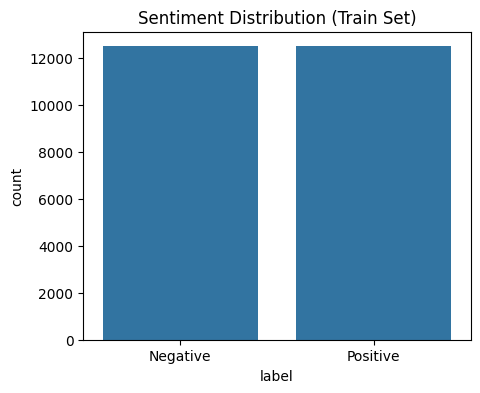

In [4]:
# Label distribution
print('Train label distribution:')
print(train_df['label'].value_counts())
print('\n0 = Negative, 1 = Positive')

plt.figure(figsize=(5, 4))
sns.countplot(x='label', data=train_df)
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.title('Sentiment Distribution (Train Set)')
plt.show()

## 3. Exploratory Data Analysis (EDA)

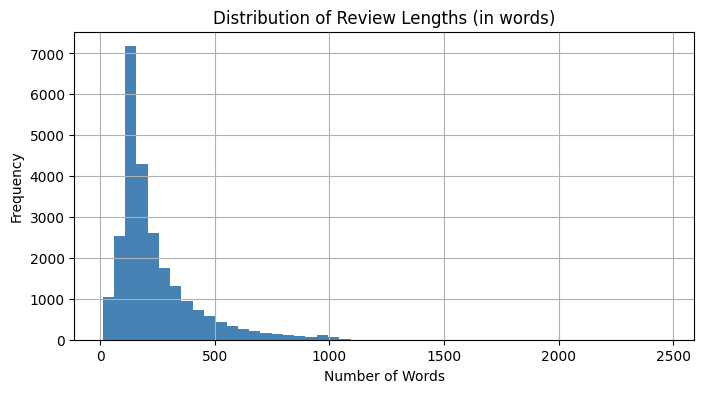

Average review length: 233.8 words
Max review length: 2470 words


In [5]:
# Review length analysis
train_df['review_length'] = train_df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))
train_df['review_length'].hist(bins=50, color='steelblue')
plt.title('Distribution of Review Lengths (in words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

print('Average review length:', round(train_df['review_length'].mean(), 1), 'words')
print('Max review length:', train_df['review_length'].max(), 'words')

In [6]:
# Sample reviews
print('Sample POSITIVE review:')
print(train_df[train_df['label'] == 1]['text'].iloc[0][:300])
print('\nSample NEGATIVE review:')
print(train_df[train_df['label'] == 0]['text'].iloc[0][:300])

Sample POSITIVE review:
Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more strik

Sample NEGATIVE review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h


## 4. Text Preprocessing

In [7]:
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing
train_df['clean_text'] = train_df['text'].apply(preprocess_text)
test_df['clean_text'] = test_df['text'].apply(preprocess_text)

print('Before preprocessing:')
print(train_df['text'].iloc[0][:200])
print('\nAfter preprocessing:')
print(train_df['clean_text'].iloc[0][:200])

Before preprocessing:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev

After preprocessing:
i rented i am curiousyellow from my video store because of all the controversy that surrounded it when it was first released in 1967 i also heard that at first it was seized by us customs if it ever t


## 5. TF-IDF Vectorization

In [8]:
# Use 10,000 most important words, remove common stopwords
tfidf = TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_test_tfidf = tfidf.transform(test_df['clean_text'])

y_train = train_df['label']
y_test = test_df['label']

print('TF-IDF Train shape:', X_train_tfidf.shape)
print('TF-IDF Test shape:', X_test_tfidf.shape)

TF-IDF Train shape: (25000, 10000)
TF-IDF Test shape: (25000, 10000)


## 6. Baseline Model 1: Logistic Regression

In [9]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)
print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=['Negative', 'Positive']))

Logistic Regression Accuracy: 0.87952
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88     12500
    Positive       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



## 7. Baseline Model 2: Naive Bayes

In [10]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)
print('Naive Bayes Accuracy:', accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb, target_names=['Negative', 'Positive']))

Naive Bayes Accuracy: 0.84728
              precision    recall  f1-score   support

    Negative       0.84      0.86      0.85     12500
    Positive       0.85      0.84      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



## 8. Confusion Matrices

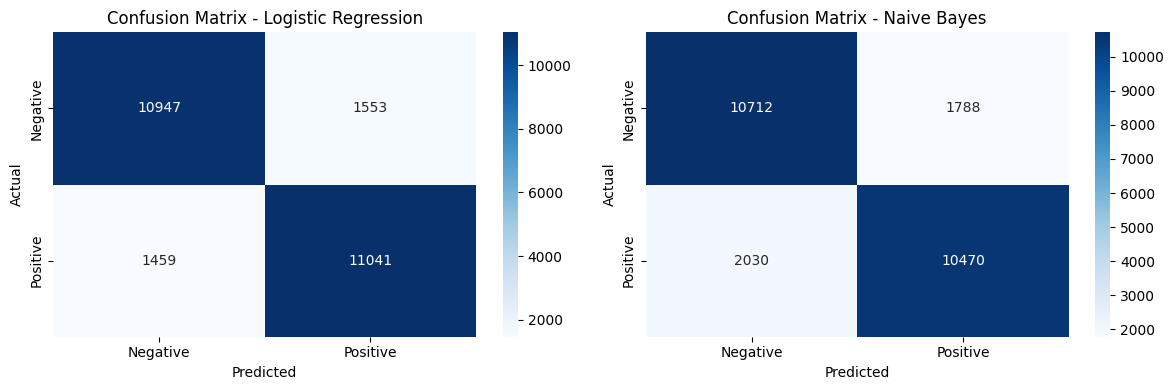

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(axes,
                              [y_pred_lr, y_pred_nb],
                              ['Logistic Regression', 'Naive Bayes']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_title(f'Confusion Matrix - {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 9. Top Predictive Words

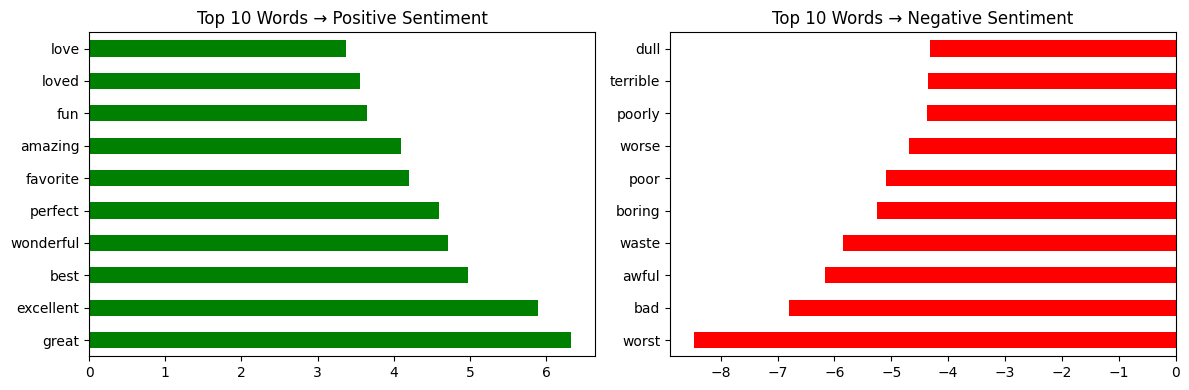

In [12]:
feature_names = tfidf.get_feature_names_out()
coefs = lr.coef_[0]

top_positive = pd.Series(coefs, index=feature_names).nlargest(10)
top_negative = pd.Series(coefs, index=feature_names).nsmallest(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

top_positive.plot(kind='barh', ax=axes[0], color='green')
axes[0].set_title('Top 10 Words → Positive Sentiment')

top_negative.plot(kind='barh', ax=axes[1], color='red')
axes[1].set_title('Top 10 Words → Negative Sentiment')

plt.tight_layout()
plt.show()

## 10. Progress Notes
- IMDB dataset is perfectly balanced (25k positive, 25k negative)
- TF-IDF with bigrams (1,2) captures word pairs like 'not good', 'very bad'
- Logistic Regression outperforms Naive Bayes on TF-IDF features
